In [1]:
import os
import warnings
import tqdm
import pandas as pd
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

In [2]:
%load_ext autoreload
%autoreload 2
import socceraction.spadl as spadl
import socceraction.vaep.formula as vaepformula

## Select data

In [3]:
# Configure file and folder names
datafolder = "/home/r-maejima/work/data-fifa"
spadl_h5 = os.path.join(datafolder, "spadl-statsbomb.h5")
predictions_h5 = os.path.join(datafolder, "predictions.h5")

In [4]:
with pd.HDFStore(spadl_h5) as spadlstore:
    games = (
        spadlstore["games"]
        .merge(spadlstore["competitions"], how='left')
        .merge(spadlstore["teams"].add_prefix('home_'), how='left')
        .merge(spadlstore["teams"].add_prefix('away_'), how='left'))
    players = spadlstore["players"]
    teams = spadlstore["teams"]
print("nb of games:", len(games))

nb of games: 1


## Compute VAEP values

In [5]:
A = []
for game in tqdm.tqdm(list(games.itertuples()), desc="Rating actions"):
    actions = pd.read_hdf(spadl_h5, f"actions/game_{game.game_id}")
    action_locations = pd.read_hdf(spadl_h5, f"action_locations/game_{game.game_id}")
    actions = (
        spadl.add_names(actions)
        .merge(players, how="left")
        .merge(teams, how="left")
        .sort_values(["game_id", "period_id", "action_id"])
        .reset_index(drop=True)
    )
    # actions = EditFunctions.add_locations_to_actions(actions, action_locations)
    gamma = 0.1
    c = 0.1
    is_vdep = True
    preds = pd.read_hdf(predictions_h5, f"game_{game.game_id}")
    values = vaepformula.value(gamma, c, is_vdep, actions, preds.scores, preds.concedes, preds.recoveries, preds.losts, preds.attacked, preds.attacks)
    A.append(pd.concat([actions, preds, values], axis=1))
A = pd.concat(A).sort_values(["game_id", "period_id", "time_seconds"]).reset_index(drop=True)
A.columns

Rating actions: 100%|██████████| 1/1 [00:00<00:00, 12.67it/s]


Index(['game_id', 'original_event_id', 'period_id', 'time_seconds', 'team_id',
       'player_id', 'start_x', 'start_y', 'end_x', 'end_y', 'type_id',
       'result_id', 'bodypart_id', 'action_id', 'type_name', 'result_name',
       'bodypart_name', 'player_name', 'nickname', 'team_name', 'scores',
       'concedes', 'recoveries', 'losts', 'attacked', 'attacks',
       'offensive_value', 'defensive_value', 'vaep_value'],
      dtype='object')

## 座標データ適用

In [6]:
%load_ext autoreload
%autoreload 2

from edit import ev, cre, pl, fm

# ファイルパスの設定
data_path_list = []
data_path_list.append("/home/r-maejima/work/soccernet/data/outputData/england_epl/2015-2016/2015-10-31 - 15-45 Chelsea 1 - 3 Liverpool")
data_path_list.append("/home/r-maejima/work/soccernet/data/outputData/england_epl/2015-2016/2016-02-07 - 19-00 Chelsea 1 - 1 Manchester United")
data_path_list.append("/home/r-maejima/work/soccernet/data/outputData/england_epl/2015-2016/2016-03-02 - 23-00 Liverpool 3 - 0 Manchester City")

game_num = 0
data_path = data_path_list[game_num]
print(data_path)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/home/r-maejima/work/soccernet/data/outputData/england_epl/2015-2016/2015-10-31 - 15-45 Chelsea 1 - 3 Liverpool


In [7]:
# ゲームIDの指定
game_ids = [3754098, 3754281, 3753991]
game_id = game_ids[game_num]
game_actions = ev.specify_game_id(A, game_id)
game_locations = ev.specify_game_id(action_locations, game_id)

In [8]:
name_ids = cre.create_name_ids(players, game_locations)
name_ids

{'Christian Benteke': (3380.0, 24),
 'Falcao': (3445.0, 33),
 'Kurt Zouma': (3456.0, 33),
 'Dejan Lovren': (3471.0, 24),
 'Willian': (3472.0, 33),
 'James Milner': (3473.0, 24),
 'Cesc Fàbregas': (3478.0, 33),
 'Mamadou Sakho': (3483.0, 24),
 'Emre Can': (3493.0, 24),
 'Philippe Coutinho': (3501.0, 24),
 'Alberto Moreno': (3515.0, 24),
 'Roberto Firmino': (3535.0, 24),
 'Eden Hazard': (3621.0, 33),
 'Jordon Ibe': (3635.0, 24),
 'Gary Cahill': (3645.0, 33),
 'Kenedy': (3666.0, 33),
 'César Azpilicueta': (3957.0, 33),
 'Adam Lallana': (4090.0, 24),
 'Nathaniel Clyne': (4590.0, 24),
 'Diego Costa': (5198.0, 33),
 'John Obi Mikel': (5475.0, 33),
 'Lucas Leiva': (7780.0, 24),
 'Martin Škrtel': (18872.0, 24),
 'John Terry': (20287.0, 33),
 'Ramires': (28100.0, 33),
 'Oscar': (40122.0, 33)}

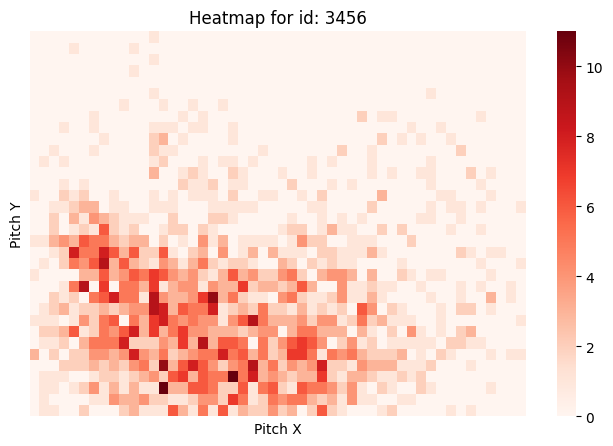

In [9]:
# ヒートマップ作成
player_id = 3456
heatmaps = cre.create_heatmaps(game_locations)
pl.plot_heatmaps(heatmaps[player_id], player_id)

In [10]:
# 各選手の出場範囲を取得
player_ranges = cre.create_player_ranges(game_locations)
player_ranges

{3380.0: (1533, 2192),
 3445.0: (1768, 2192),
 3456.0: (0, 2192),
 3471.0: (2132, 2192),
 3472.0: (0, 2192),
 3473.0: (0, 1532),
 3478.0: (1665, 2192),
 3483.0: (0, 2192),
 3493.0: (0, 2192),
 3501.0: (0, 2192),
 3515.0: (0, 2192),
 3535.0: (0, 1767),
 3621.0: (0, 1440),
 3635.0: (1768, 2192),
 3645.0: (0, 2192),
 3666.0: (1441, 2192),
 3957.0: (0, 1767),
 4090.0: (0, 2131),
 4590.0: (0, 2192),
 5198.0: (0, 2192),
 5475.0: (0, 1664),
 7780.0: (0, 2192),
 18872.0: (0, 2192),
 20287.0: (0, 2192),
 28100.0: (0, 2192),
 40122.0: (0, 2192)}

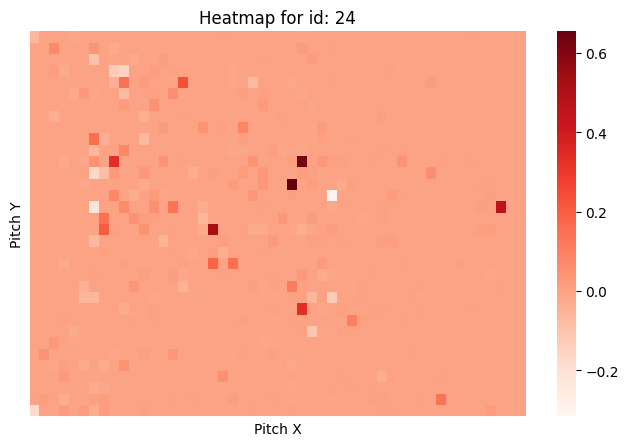

In [11]:
# チームごとのアクションのヒートマップを確認
team_id = 24
team_actions = game_actions[game_actions["team_id"] == team_id]
vaep_map = ev.get_vaep_map(team_actions, True)
pl.plot_heatmaps(vaep_map, team_id)

In [12]:
# 選手の座標スコアを取得
loc_values = ev.calc_all_location_value(game_actions, heatmaps, name_ids, player_ranges, gamma)
loc_values.sort_values("location_value", ascending=False)

,player_id,player_name,location_value,off_location_value,def_location_value
17,4090.0,Adam Lallana,14.730211,11.274748,34.554622
18,4590.0,Nathaniel Clyne,14.233230,9.685580,45.476492
22,18872.0,Martin Škrtel,10.888966,7.554717,33.342489
21,7780.0,Lucas Leiva,10.557589,8.041361,25.162285
9,3501.0,Philippe Coutinho,9.712209,4.293939,54.182697
8,3493.0,Emre Can,9.535111,5.337416,41.976958
7,3483.0,Mamadou Sakho,8.282520,3.715677,45.668430
10,3515.0,Alberto Moreno,8.115091,1.838873,62.762185
11,3535.0,Roberto Firmino,8.023861,6.044746,19.791147
24,28100.0,Ramires,6.140388,2.216747,39.236407


## Analyse VAEP ratings
### Most valuable players

In [13]:
A["count"] = 1

# Compute each player's number of actions and total VAEP values
playersR = (
    A[["player_id", "vaep_value", "offensive_value", "defensive_value", "count"]]
    .groupby(["player_id"])
    .sum()
    .reset_index()
)
# Add player names
playersR = playersR.merge(players[["player_id", "nickname", "player_name"]], how="left")
playersR["player_name"] = playersR[["nickname","player_name"]].apply(lambda x: x.iloc[0] if x.iloc[0] else x.iloc[1], axis=1)
# Show results
playersR = playersR[["player_id", "player_name", "vaep_value", "offensive_value", "defensive_value", "count"]]
playersR.sort_values("vaep_value", ascending=False)

,player_id,player_name,vaep_value,offensive_value,defensive_value,count
19,4090.0,Adam Lallana,1.736066,1.444714,2.913520,77
12,3535.0,Roberto Firmino,1.376955,0.769994,6.069611,108
23,7780.0,Lucas Leiva,0.881710,0.703031,1.786794,159
14,3621.0,Eden Hazard,0.701484,0.586846,1.146382,54
8,3483.0,Mamadou Sakho,0.629654,0.362754,2.668997,147
27,40122.0,Oscar,0.584285,0.281276,3.030085,113
13,3539.0,Simon Mignolet,0.538648,0.493752,0.448958,42
5,3472.0,Willian,0.459323,0.046044,4.132782,103
11,3515.0,Alberto Moreno,0.455917,-0.144260,6.001769,111
24,18872.0,Martin Škrtel,0.454732,0.210346,2.443860,93


In [14]:
# ファイルマネージャー作成
manager = fm.FileManager(data_path)

# 背番号と名前の対応関係作成
player_names, player_infos = manager.load_player_file()
print(player_infos)

{'Nathaniel Clyne': {'team_name': 'Liverpool', 'jersey': '2', 'position': 'DF', 'rating': 6.8}, 'Martin Škrtel': {'team_name': 'Liverpool', 'jersey': '37', 'position': 'DF', 'rating': 6.9}, 'Mamadou Sakho': {'team_name': 'Liverpool', 'jersey': '17', 'position': 'DF', 'rating': 6.9}, 'Alberto Moreno': {'team_name': 'Liverpool', 'jersey': '18', 'position': 'DF', 'rating': 7.0}, 'James Milner': {'team_name': 'Liverpool', 'jersey': '7', 'position': 'MF', 'rating': 6.4}, 'Lucas Leiva': {'team_name': 'Liverpool', 'jersey': '21', 'position': 'MF', 'rating': 7.0}, 'Emre Can': {'team_name': 'Liverpool', 'jersey': '23', 'position': 'MF', 'rating': 6.9}, 'Adam Lallana': {'team_name': 'Liverpool', 'jersey': '20', 'position': 'MF', 'rating': 7.2}, 'Philippe Coutinho': {'team_name': 'Liverpool', 'jersey': '10', 'position': 'MF', 'rating': 8.8}, 'Roberto Firmino': {'team_name': 'Liverpool', 'jersey': '11', 'position': 'FW', 'rating': 7.3}, 'Christian Benteke': {'team_name': 'Liverpool', 'jersey': '9'

In [15]:
# キーパーの除外
keepers = cre.create_keepers(player_infos)
print(keepers)
playersR = ev.delete_players(playersR, keepers)

['Simon Mignolet', 'Asmir Begović']


In [16]:
# 座標スコアの追加
playersR = ev.add_location_value_to_playersR(playersR, loc_values)
playersR

,player_id,player_name,vaep_value,offensive_value,defensive_value,count,location_value,off_location_value,def_location_value
0,3380.0,Christian Benteke,-0.068275,-0.093488,0.252129,24,1.184557,0.948502,2.360553
1,3445.0,Falcao,0.028104,0.008304,0.198005,17,0.454422,0.389924,0.644977
2,3456.0,Kurt Zouma,0.203604,-0.075344,2.789483,51,4.370539,1.186940,31.835991
3,3471.0,Dejan Lovren,0.003861,0.002663,0.011981,3,0.000000,0.000000,0.000000
4,3472.0,Willian,0.459323,0.046044,4.132782,103,5.686318,1.679244,40.070731
5,3473.0,James Milner,-0.031554,-0.092288,0.607338,69,1.221322,0.021531,11.997915
6,3478.0,Cesc Fàbregas,0.065422,0.075437,-0.100142,52,0.602353,0.387243,2.151099
7,3483.0,Mamadou Sakho,0.629654,0.362754,2.668997,147,8.282520,3.715677,45.668430
8,3493.0,Emre Can,0.124118,-0.077003,2.011204,142,9.535111,5.337416,41.976958
9,3501.0,Philippe Coutinho,0.165601,0.103652,0.619490,112,9.712209,4.293939,54.182697


In [17]:
# 選手情報を追加
playersR = ev.add_player_infos(playersR, player_infos)
playersR.sort_values("rating", ascending=False)

,player_id,player_name,vaep_value,offensive_value,defensive_value,count,location_value,off_location_value,def_location_value,position,rating
9,3501.0,Philippe Coutinho,0.165601,0.103652,0.619490,112,9.712209,4.293939,54.182697,MF,8.8
24,28100.0,Ramires,0.337651,0.217837,1.198145,99,6.140388,2.216747,39.236407,MF,7.7
0,3380.0,Christian Benteke,-0.068275,-0.093488,0.252129,24,1.184557,0.948502,2.360553,FW,7.5
14,3645.0,Gary Cahill,0.069633,-0.109342,1.789751,81,4.826296,1.047352,37.789442,DF,7.3
11,3535.0,Roberto Firmino,1.376955,0.769994,6.069611,108,8.023861,6.044746,19.791147,FW,7.3
20,5475.0,John Obi Mikel,0.428102,0.048372,3.797300,76,3.812780,1.399718,24.130625,MF,7.2
17,4090.0,Adam Lallana,1.736066,1.444714,2.913520,77,14.730211,11.274748,34.554622,MF,7.2
4,3472.0,Willian,0.459323,0.046044,4.132782,103,5.686318,1.679244,40.070731,FW,7.1
10,3515.0,Alberto Moreno,0.455917,-0.144260,6.001769,111,8.115091,1.838873,62.762185,DF,7.0
21,7780.0,Lucas Leiva,0.881710,0.703031,1.786794,159,10.557589,8.041361,25.162285,MF,7.0


In [18]:
# 保存
if is_vdep:
    file_path = os.path.join(data_path, "playersR.pkl")
else:
    file_path = os.path.join(data_path, "playersR_vaep.pkl")    
playersR.to_pickle(file_path)

# 相関係数算出

In [19]:
%load_ext autoreload
%autoreload 2

from edit import ev, pl

# ファイルパスの設定
data_path_list = []
data_path_list.append("/home/r-maejima/work/soccernet/data/outputData/england_epl/2015-2016/2015-10-31 - 15-45 Chelsea 1 - 3 Liverpool")
data_path_list.append("/home/r-maejima/work/soccernet/data/outputData/england_epl/2015-2016/2016-02-07 - 19-00 Chelsea 1 - 1 Manchester United")
data_path_list.append("/home/r-maejima/work/soccernet/data/outputData/england_epl/2015-2016/2016-03-02 - 23-00 Liverpool 3 - 0 Manchester City")

game_num = 0
data_path = data_path_list[game_num]
print(data_path)

# playersRの読み込み
playersR_list = []
non_vdep_list = []
for data_path in data_path_list:
    file_path = os.path.join(data_path, "playersR.pkl")
    playersR_list.append(pd.read_pickle(file_path))
    file_path = os.path.join(data_path, "playersR_vaep.pkl")
    non_vdep_list.append(pd.read_pickle(file_path))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/home/r-maejima/work/soccernet/data/outputData/england_epl/2015-2016/2015-10-31 - 15-45 Chelsea 1 - 3 Liverpool


In [20]:
# βの算出
beta = ev.calc_beta(playersR_list)
print(f"beta = {beta:.4f}")

beta = 0.1000


In [21]:
# トータルスコアの計算
ev.calc_total_score(playersR_list, beta)
playersR_list[game_num].sort_values("total_value", ascending=False)

,player_id,player_name,vaep_value,offensive_value,defensive_value,count,location_value,off_location_value,def_location_value,position,rating,total_value
17,4090.0,Adam Lallana,1.736066,1.444714,2.913520,77,14.730211,11.274748,34.554622,MF,7.2,3.208361
11,3535.0,Roberto Firmino,1.376955,0.769994,6.069611,108,8.023861,6.044746,19.791147,FW,7.3,2.178945
21,7780.0,Lucas Leiva,0.881710,0.703031,1.786794,159,10.557589,8.041361,25.162285,MF,7.0,1.936949
18,4590.0,Nathaniel Clyne,0.277668,-0.096615,3.742833,112,14.233230,9.685580,45.476492,DF,6.8,1.700289
22,18872.0,Martin Škrtel,0.454732,0.210346,2.443860,93,10.888966,7.554717,33.342489,DF,6.9,1.543092
7,3483.0,Mamadou Sakho,0.629654,0.362754,2.668997,147,8.282520,3.715677,45.668430,DF,6.9,1.457497
10,3515.0,Alberto Moreno,0.455917,-0.144260,6.001769,111,8.115091,1.838873,62.762185,DF,7.0,1.267026
25,40122.0,Oscar,0.584285,0.281276,3.030085,113,5.567137,1.826045,37.410920,FW,7.0,1.140724
9,3501.0,Philippe Coutinho,0.165601,0.103652,0.619490,112,9.712209,4.293939,54.182697,MF,8.8,1.136343
8,3493.0,Emre Can,0.124118,-0.077003,2.011204,142,9.535111,5.337416,41.976958,MF,6.9,1.077159


In [22]:
# 得点者
scorer = []
scorer.append(["Philippe Coutinho", "Ramires", "Christian Benteke"])
scorer.append(["Adam Lallna", "James Milner", "Roberto Firmino"])
scorer.append(["Jesse Lingard", "Diego Costa"])

In [23]:
# 分布正規化
ev.calc_is_scorer(playersR_list, scorer)
ev.batch_normalization(playersR_list)
ev.calc_is_scorer(non_vdep_list, scorer)
ev.batch_normalization(non_vdep_list)
playersR_list[game_num]

,player_id,player_name,vaep_value,offensive_value,defensive_value,count,location_value,off_location_value,def_location_value,position,rating,total_value,is_scorer,rating_dist_align
0,3380.0,Christian Benteke,-0.068275,-0.093488,0.252129,24,1.184557,0.948502,2.360553,FW,7.5,0.050122,True,6.204027
1,3445.0,Falcao,0.028104,0.008304,0.198005,17,0.454422,0.389924,0.644977,FW,6.0,0.073524,False,6.000000
2,3456.0,Kurt Zouma,0.203604,-0.075344,2.789483,51,4.370539,1.186940,31.835991,DF,6.3,0.640443,False,6.300000
3,3471.0,Dejan Lovren,0.003861,0.002663,0.011981,3,0.000000,0.000000,0.000000,MF,6.0,0.003861,False,6.000000
4,3472.0,Willian,0.459323,0.046044,4.132782,103,5.686318,1.679244,40.070731,FW,7.1,1.027674,False,7.100000
5,3473.0,James Milner,-0.031554,-0.092288,0.607338,69,1.221322,0.021531,11.997915,MF,6.4,0.090518,False,6.400000
6,3478.0,Cesc Fàbregas,0.065422,0.075437,-0.100142,52,0.602353,0.387243,2.151099,MF,6.2,0.125628,False,6.200000
7,3483.0,Mamadou Sakho,0.629654,0.362754,2.668997,147,8.282520,3.715677,45.668430,DF,6.9,1.457497,False,6.900000
8,3493.0,Emre Can,0.124118,-0.077003,2.011204,142,9.535111,5.337416,41.976958,MF,6.9,1.077159,False,6.900000
9,3501.0,Philippe Coutinho,0.165601,0.103652,0.619490,112,9.712209,4.293939,54.182697,MF,8.8,1.136343,True,7.888757


In [ ]:
# 得点者の除去
for i in range(2):
    playersR_list[i] = ev.delete_players(playersR_list[i], scorer[i])
    non_vdep_list[i] = ev.delete_players(non_vdep_list[i], scorer[i])
playersR_list[game_num]

In [24]:
# 相関係数の計算
game_num = 0
playersR = playersR_list[game_num]
non_vdep = non_vdep_list[game_num]
# rating = "rating"
rating = "rating_dist_align"
pearson_corr, spearman_corr = ev.calc_corr(non_vdep, "vaep_value", rating)
print(f"ピアソン相関係数(VAEP): {pearson_corr:.3f}")
print(f"スピアマン順位相関係数(VAEP): {spearman_corr:.3f}")
pearson_corr, spearman_corr = ev.calc_corr(playersR, "vaep_value", rating)
print(f"ピアソン相関係数(Maejima): {pearson_corr:.3f}")
print(f"スピアマン順位相関係数(Maejima): {spearman_corr:.3f}")
pearson_corr, spearman_corr = ev.calc_corr(playersR, "total_value", rating)
print(f"ピアソン相関係数(Total): {pearson_corr:.3f}")
print(f"スピアマン順位相関係数(Total): {spearman_corr:.3f}")
pearson_corr, spearman_corr = ev.calc_corr(playersR, "location_value", rating)
print(f"ピアソン相関係数(Loc): {pearson_corr:.3f}")
print(f"スピアマン順位相関係数(Loc): {spearman_corr:.3f}")

ピアソン相関係数(VAEP): 0.142
スピアマン順位相関係数(VAEP): 0.190
ピアソン相関係数(Maejima): 0.443
スピアマン順位相関係数(Maejima): 0.493
ピアソン相関係数(Total): 0.599
スピアマン順位相関係数(Total): 0.641
ピアソン相関係数(Loc): 0.635
スピアマン順位相関係数(Loc): 0.628


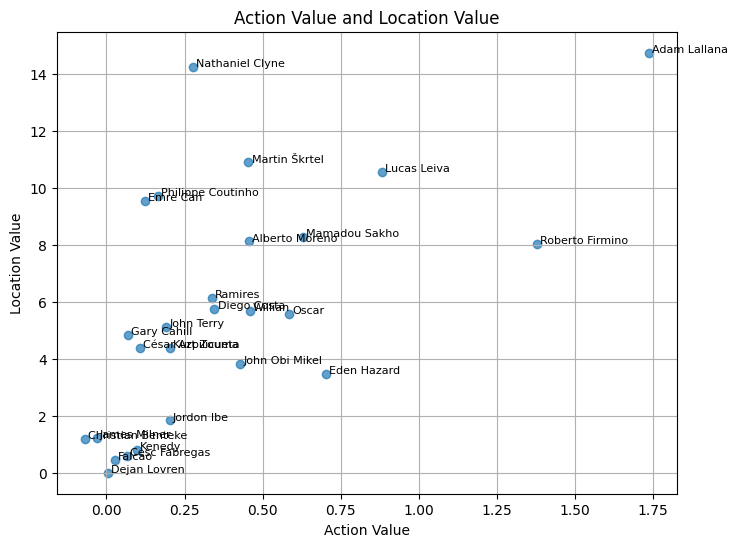

In [25]:
# アクションスコアと座標スコアのグラフ
pl.plot_value(playersR)

In [26]:
# 全試合の評価値
playersR_all = pd.concat(playersR_list, ignore_index=True)
non_vdep_all = pd.concat(non_vdep_list, ignore_index=True)
playersR_all.sort_values("player_id", ascending=False)

,player_id,player_name,vaep_value,offensive_value,defensive_value,count,location_value,off_location_value,def_location_value,position,rating,total_value,is_scorer,rating_dist_align
51,40122.0,Oscar,-0.076416,-0.027344,-0.490715,52,1.431177,0.271118,11.600582,FW,6.6,0.066631,False,6.600000
25,40122.0,Oscar,0.584285,0.281276,3.030085,113,5.567137,1.826045,37.410920,FW,7.0,1.140724,False,7.000000
77,38412.0,Kolo Touré,0.847108,0.164976,6.821315,96,13.021940,4.982936,80.390037,DF,7.5,2.148660,False,7.500000
24,28100.0,Ramires,0.337651,0.217837,1.198145,99,6.140388,2.216747,39.236407,MF,7.7,0.951387,True,6.463216
76,20302.0,Gaël Clichy,0.707082,0.001041,7.060409,111,4.868312,-0.004254,48.725661,DF,7.3,1.193673,False,7.300000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55,3090.0,Nicolás Otamendi,0.677023,-0.014863,6.918864,99,7.790181,0.074890,77.152911,DF,7.3,1.455657,False,7.300000
54,3064.0,David Silva,0.049988,-0.106091,1.560790,153,5.517712,0.428144,50.895681,MF,6.5,0.601487,False,6.500000
53,3054.0,Fernandinho,0.327693,0.087870,2.398232,71,2.559184,0.389904,21.692794,MF,6.3,0.583485,False,6.300000
52,3052.0,Pablo Zabaleta,0.565788,0.046872,5.189160,118,6.570600,0.606692,59.639080,DF,5.7,1.222524,False,5.700000


In [27]:
# 相関係数の計算
pearson_corr, spearman_corr = ev.calc_corr(non_vdep_all, "vaep_value", rating)
print(f"ピアソン相関係数(VAEP): {pearson_corr:.3f}")
print(f"スピアマン順位相関係数(VAEP): {spearman_corr:.3f}")
pearson_corr, spearman_corr = ev.calc_corr(playersR_all, "vaep_value", rating)
print(f"ピアソン相関係数(Maejima): {pearson_corr:.3f}")
print(f"スピアマン順位相関係数(Maejima): {spearman_corr:.3f}")
pearson_corr, spearman_corr = ev.calc_corr(playersR_all, "total_value", rating)
print(f"ピアソン相関係数(Total): {pearson_corr:.3f}")
print(f"スピアマン順位相関係数(Total): {spearman_corr:.3f}")
pearson_corr, spearman_corr = ev.calc_corr(playersR_all, "location_value", rating)
print(f"ピアソン相関係数(Loc): {pearson_corr:.3f}")
print(f"スピアマン順位相関係数(Loc): {spearman_corr:.3f}")

ピアソン相関係数(VAEP): 0.302
スピアマン順位相関係数(VAEP): 0.223
ピアソン相関係数(Maejima): 0.497
スピアマン順位相関係数(Maejima): 0.471
ピアソン相関係数(Total): 0.614
スピアマン順位相関係数(Total): 0.573
ピアソン相関係数(Loc): 0.618
スピアマン順位相関係数(Loc): 0.617


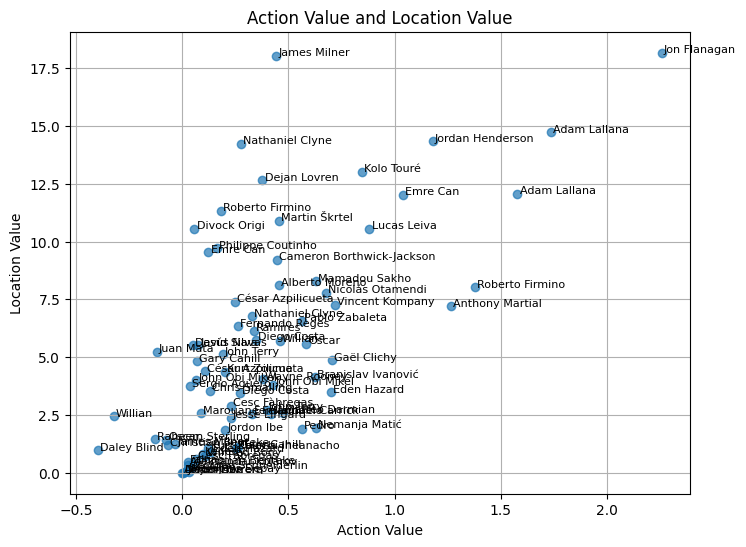

In [28]:
# アクションスコアと座標スコアのグラフ
pl.plot_value(playersR_all)

In [29]:
# 相関係数の計算(ポジション別)
position_list = ["FW", "MF", "DF"]
playersR = playersR_all[playersR_all["position"] == position_list[0]]
pearson_corr, spearman_corr = ev.calc_corr(playersR, "vaep_value", rating)
print(f"ピアソン相関係数(VAEP): {pearson_corr:.3f}")
print(f"スピアマン順位相関係数(VAEP): {spearman_corr:.3f}")

pearson_corr, spearman_corr = ev.calc_corr(playersR, "total_value", rating)
print(f"ピアソン相関係数(Total): {pearson_corr:.3f}")
print(f"スピアマン順位相関係数(Total): {spearman_corr:.3f}")
pearson_corr, spearman_corr = ev.calc_corr(playersR, "location_value", rating)
print(f"ピアソン相関係数(Loc): {pearson_corr:.3f}")
print(f"スピアマン順位相関係数(Loc): {spearman_corr:.3f}")
pearson_corr, spearman_corr = ev.calc_corr(playersR, "off_location_value", rating)
print(f"ピアソン相関係数(Loc-off): {pearson_corr:.3f}")
print(f"スピアマン順位相関係数(Loc-off): {spearman_corr:.3f}")
pearson_corr, spearman_corr = ev.calc_corr(playersR, "def_location_value", rating)
print(f"ピアソン相関係数(Loc-def): {pearson_corr:.3f}")
print(f"スピアマン順位相関係数(Loc-def): {spearman_corr:.3f}")

ピアソン相関係数(VAEP): 0.528
スピアマン順位相関係数(VAEP): 0.449
ピアソン相関係数(Total): 0.680
スピアマン順位相関係数(Total): 0.514
ピアソン相関係数(Loc): 0.679
スピアマン順位相関係数(Loc): 0.621
ピアソン相関係数(Loc-off): 0.633
スピアマン順位相関係数(Loc-off): 0.538
ピアソン相関係数(Loc-def): 0.606
スピアマン順位相関係数(Loc-def): 0.560


In [30]:
# Normalize for minutes played
pg = pd.read_hdf(spadl_h5, "player_games")
pg = pg[pg.game_id.isin(games.game_id)]
mp = pg[["player_id", "minutes_played"]].groupby("player_id").sum().reset_index()

stats = playersR.merge(mp)
stats = stats[stats.minutes_played > 180] # at least two full games played
stats["vaep_rating"] = stats.vaep_value * 90 / stats.minutes_played
stats["offensive_rating"] = stats.offensive_value * 90 / stats.minutes_played
stats["defensive_rating"] = stats.defensive_value * 90 / stats.minutes_played
stats.sort_values("vaep_rating",ascending=False)[:10]

,player_id,player_name,vaep_value,offensive_value,defensive_value,count,location_value,off_location_value,def_location_value,position,rating,total_value,is_scorer,rating_dist_align,minutes_played,vaep_rating,offensive_rating,defensive_rating


In [31]:
# Compute each player's number of actions and total offensive values
playersR.sort_values("offensive_value", ascending=False)[:10]

,player_id,player_name,vaep_value,offensive_value,defensive_value,count,location_value,off_location_value,def_location_value,position,rating,total_value,is_scorer,rating_dist_align
49,20039.0,Anthony Martial,1.266938,0.991802,2.751367,92,7.194670,3.866827,33.278425,FW,6.6,1.986051,False,6.6
68,4090.0,Adam Lallana,1.578034,0.848949,7.290845,132,12.055664,6.438060,56.176039,FW,9.9,2.783006,False,9.9
11,3535.0,Roberto Firmino,1.376955,0.769994,6.069611,108,8.023861,6.044746,19.791147,FW,7.3,2.178945,False,7.3
41,3958.0,Pedro,0.564089,0.550300,0.137890,42,1.895773,1.735850,1.599229,FW,6.2,0.753572,False,6.2
25,40122.0,Oscar,0.584285,0.281276,3.030085,113,5.567137,1.826045,37.410920,FW,7.0,1.140724,False,7.0
35,3538.0,Wayne Rooney,0.381803,0.256099,1.257041,83,4.041528,3.084589,9.569387,FW,7.8,0.785757,False,7.8
44,5198.0,Diego Costa,0.271888,0.173006,0.988820,79,3.427758,2.167838,12.599197,FW,7.5,0.614495,False,7.5
19,5198.0,Diego Costa,0.345943,0.170472,1.754715,75,5.740087,2.705134,30.349533,FW,6.2,0.919669,False,6.2
13,3635.0,Jordon Ibe,0.202535,0.143745,0.587905,11,1.840154,1.703279,1.368753,FW,6.5,0.386460,False,6.5
58,3237.0,Sergio Agüero,0.037462,0.097123,-0.596616,69,3.734524,0.783530,29.509941,FW,6.4,0.410730,False,6.4


In [32]:
# Compute each player's number of actions and total defensive values
playersR.sort_values("defensive_value", ascending=False)[:10]

,player_id,player_name,vaep_value,offensive_value,defensive_value,count,location_value,off_location_value,def_location_value,position,rating,total_value,is_scorer,rating_dist_align
68,4090.0,Adam Lallana,1.578034,0.848949,7.290845,132,12.055664,6.438060,56.176039,FW,9.9,2.783006,False,9.9
11,3535.0,Roberto Firmino,1.376955,0.769994,6.069611,108,8.023861,6.044746,19.791147,FW,7.3,2.178945,False,7.3
61,3473.0,James Milner,0.442137,-0.102856,5.449925,93,18.048606,10.102445,79.461613,FW,8.6,2.246107,False,8.6
4,3472.0,Willian,0.459323,0.046044,4.132782,103,5.686318,1.679244,40.070731,FW,7.1,1.027674,False,7.1
27,3293.0,Jesse Lingard,0.228405,-0.084314,3.127195,86,2.381096,0.847873,15.332225,FW,7.6,0.466398,False,7.6
25,40122.0,Oscar,0.584285,0.281276,3.030085,113,5.567137,1.826045,37.410920,FW,7.0,1.140724,False,7.0
49,20039.0,Anthony Martial,1.266938,0.991802,2.751367,92,7.194670,3.866827,33.278425,FW,6.6,1.986051,False,6.6
67,3708.0,Kelechi Iheanacho,0.254985,-0.002122,2.571065,23,1.054716,-0.009781,10.644972,FW,6.2,0.360404,False,6.2
19,5198.0,Diego Costa,0.345943,0.170472,1.754715,75,5.740087,2.705134,30.349533,FW,6.2,0.919669,False,6.2
35,3538.0,Wayne Rooney,0.381803,0.256099,1.257041,83,4.041528,3.084589,9.569387,FW,7.8,0.785757,False,7.8


### (optional) inspect Belgium's top 10 most valuable non-shot actions

In [ ]:
import matplotsoccer

sorted_A = A.sort_values("vaep_value", ascending=False)
sorted_A = sorted_A[sorted_A.team_name == "Belgium"] # view only actions from Belgium
sorted_A = sorted_A[~sorted_A.type_name.str.contains("shot")] #eliminate shots

def get_time(period_id,time_seconds):
    m = int((period_id-1)*45 + time_seconds // 60)
    s = int(time_seconds % 60)
    return f"{m}m{s}s"

for j in range(0, 10):
    row = list(sorted_A[j:j+1].itertuples())[0]
    i = row.Index
    gamma = A[i - 3 : i+2].copy()
    
    gamma["player_name"] = gamma[["nickname", "player_name"]].apply(lambda x: x.iloc[0] if x.iloc[0] else x.iloc[1], axis=1)
    
    g = list(games[games.game_id == gamma.game_id.values[0]].itertuples())[0]
    game_info = f"{g.game_date} {g.home_team_name} {g.home_score}-{g.away_score} {g.away_team_name}"
    minute = int((row.period_id-1)*45 + row.time_seconds // 60)
    print(f"{game_info} {minute}' {row.type_name} {row.player_name}")

    gamma["scores"] = gamma.scores.apply(lambda x : "%.3f" % x )
    gamma["vaep_value"] = gamma.vaep_value.apply(lambda x : "%.3f" % x )
    gamma["time"] = gamma[["period_id", "time_seconds"]].apply(lambda x: get_time(*x),axis=1)
    cols = ["time", "type_name", "player_name", "team_name", "scores", "vaep_value"]
    matplotsoccer.actions(gamma[["start_x", "start_y", "end_x",  "end_y"]],
                gamma.type_name,
                team=gamma.team_name,
                result = gamma.result_name == "success",
                label=gamma[cols],
                labeltitle = cols,
                zoom=False)